In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
print("1. Chargement des données issues de l'ARIMA")
train = pd.read_csv("train_avec_arima.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_avec_arima.csv", index_col=0, parse_dates=True)

print("2. Isolement des variables macroéconomiques (Features)")
colonnes_features = ["Brent", "EUR_USD", "EuroStoxx", "VIX"]
X_train = train[colonnes_features]
X_test = test[colonnes_features]

y_train_residus = train['Residus_ARIMA']

1. Chargement des données issues de l'ARIMA
2. Isolement des variables macroéconomiques (Features)


In [5]:
print("ENTRAÎNEMENT XGBOOST CLASSIQUE")
xgb = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train_residus)

test['Pred_Erreur_XGB'] = xgb.predict(X_test)
test['Pred_Finale_Hybride'] = test['Pred_ARIMA'] + test['Pred_Erreur_XGB']

rmse_base = np.sqrt(mean_squared_error(test['Cible'], test['Pred_ARIMA']))
rmse_hybride = np.sqrt(mean_squared_error(test['Cible'], test['Pred_Finale_Hybride']))
mae_hybride = mean_absolute_error(test['Cible'], test['Pred_Finale_Hybride'])

print(f"Erreur Modèle Économétrique seul : {rmse_base:.5f}")
print(f"Erreur Modèle Hybride ML       : {rmse_hybride:.5f}\n")
print(f"MAE Modèle Hybride ML        : {mae_hybride:.5f}\n")

ENTRAÎNEMENT XGBOOST CLASSIQUE
Erreur Modèle Économétrique seul : 0.01201
Erreur Modèle Hybride ML       : 0.01257

MAE Modèle Hybride ML        : 0.00907



In [8]:
print(test[['Cible', 'Pred_ARIMA', 'Pred_Erreur_XGB']].tail())

               Cible  Pred_ARIMA  Pred_Erreur_XGB
Date                                             
2026-03-24  0.027165     0.00046        -0.001540
2026-03-25  0.006342     0.00046         0.001661
2026-03-26  0.021389     0.00046         0.001941
2026-03-27  0.002558     0.00046        -0.001177
2026-03-30  0.027075     0.00046         0.001179


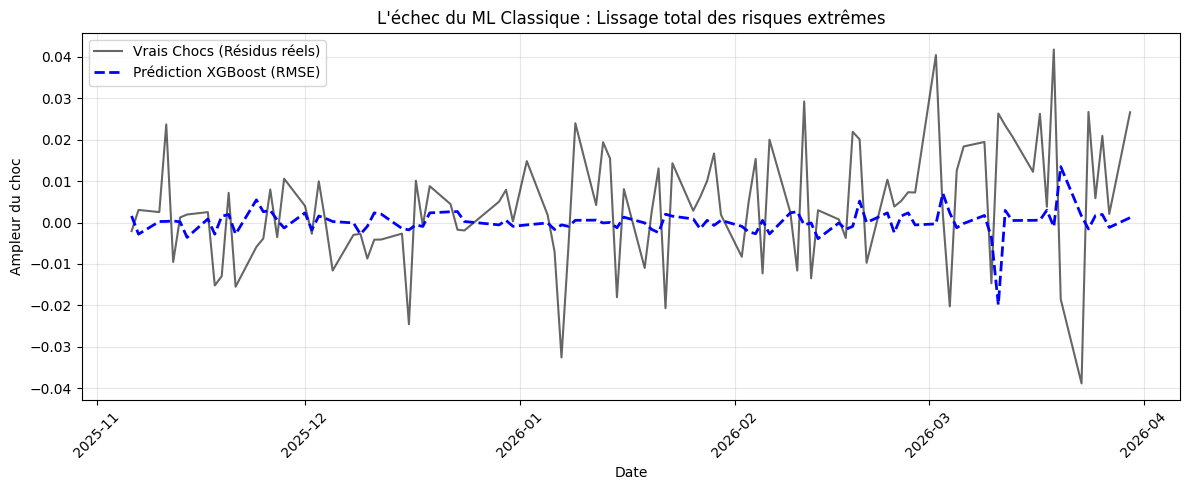

In [ ]:
test['Residus_Vrais'] = test['Cible'] - test['Pred_ARIMA']

plt.figure(figsize=(12, 5))

dates_visu = test.index[-100:]
chocs_reels = test['Residus_Vrais'].iloc[-100:]
prediction_lisse = test['Pred_Erreur_XGB'].iloc[-100:]

plt.plot(dates_visu, chocs_reels, label="Vrais Chocs (Résidus réels)", color='black', alpha=0.6)
plt.plot(dates_visu, prediction_lisse, label="Prédiction XGBoost (RMSE)", color='blue', linestyle='dashed', linewidth=2)

plt.title("L'échec du ML Classique : Lissage total des risques extrêmes")
plt.xlabel("Date")
plt.ylabel("Ampleur du choc")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

### Analyse Visuelle : L'aveuglement du modèle RMSE et la nécessité du Pivot

Le graphique ci-dessus illustre parfaitement le danger d'appliquer aveuglément des algorithmes de Machine Learning standard. 

**L'échec de la prédiction de la moyenne :** 
On observe très clairement que la réalité du marché (la courbe grise) est ponctuée de chocs quotidiens violents, avec des amplitudes extrêmes dépassant régulièrement la barre des +3% ou plongeant vers les -4%. Face à cette volatilité, notre modèle XGBoost classique (la courbe bleue en pointillés) produit une prédiction presque totalement plate, oscillant timidement autour de zéro. 

Parce qu'il est configuré pour minimiser l'erreur quadratique moyenne (RMSE), l'algorithme a mathématiquement raison : la moyenne d'un choc imprévisible est zéro. Mais financièrement, c'est un désastre. Il lisse totalement le risque extrême. Si un département des risques utilisait ce modèle pour allouer son capital réglementaire, il serait sous-couvert au premier krach.

**Le Pivot Méthodologique : La Régression Quantile (Value at Risk)**
Puisque modéliser la moyenne des résidus est inutile, nous devons radicalement changer la mission. L'objectif n'est plus de deviner la direction exacte du marché, mais d'estimer **le pire scénario possible**.

Nous allons remplacer notre XGBoost classique par un *Gradient Boosting Regressor* en modifiant sa fonction de coût pour une **Perte Quantile (Pinball Loss)**, paramétrée sur le 5ème centile (`alpha = 0.05`). Le modèle va désormais apprendre de nos variables macroéconomiques (VIX, Brent, EuroStoxx) pour tracer un "plancher" dynamique.

In [10]:
print("ENTRAÎNEMENT DU MODÈLE DE VALUE AT RISK (VaR 95%)")

modele_risque = GradientBoostingRegressor(loss='quantile', alpha=0.05, n_estimators=50, max_depth=3, random_state=42)
modele_risque.fit(X_train, y_train_residus)

test['Pred_Erreur_VaR'] = modele_risque.predict(X_test)
test['Pred_VaR_Hybride'] = test['Pred_ARIMA'] + test['Pred_Erreur_VaR']

ENTRAÎNEMENT DU MODÈLE DE VALUE AT RISK (VaR 95%)


In [ ]:
depassements = test['Cible'] < test['Pred_VaR_Hybride']
nombre_depassements = depassements.sum()
pourcentage_depassements = (nombre_depassements / len(test)) * 100

var_moyenne = test['Pred_VaR_Hybride'].mean()
var_max = test['Pred_VaR_Hybride'].min() 
var_min = test['Pred_VaR_Hybride'].max() 

print("BACKTESTING DE LA VALUE AT RISK (VaR 95%) SUR L'ÉCHANTILLON TEST")
print(f"Nombre total de jours testés : {len(test)}")
print(f"Nombre de fois où le marché a brisé la VaR : {nombre_depassements}")
print(f"Taux de dépassement (Hit Rate) : {pourcentage_depassements:.2f}% (Cible théorique : ~5.00%)")
print("-" * 50)
print(f"VaR Moyenne anticipée : {var_moyenne * 100:.2f}%")
print(f"Pire chute anticipée (VaR Max) : {var_max * 100:.2f}%")

BACKTESTING DE LA VALUE AT RISK (VaR 95%) SUR L'ÉCHANTILLON TEST
Nombre total de jours testés : 577
Nombre de fois où le marché a brisé la VaR : 17
Taux de dépassement (Hit Rate) : 2.95% (Cible théorique : ~5.00%)
--------------------------------------------------
VaR Moyenne anticipée : -2.35%
Pire chute anticipée (VaR Max) : -6.24%


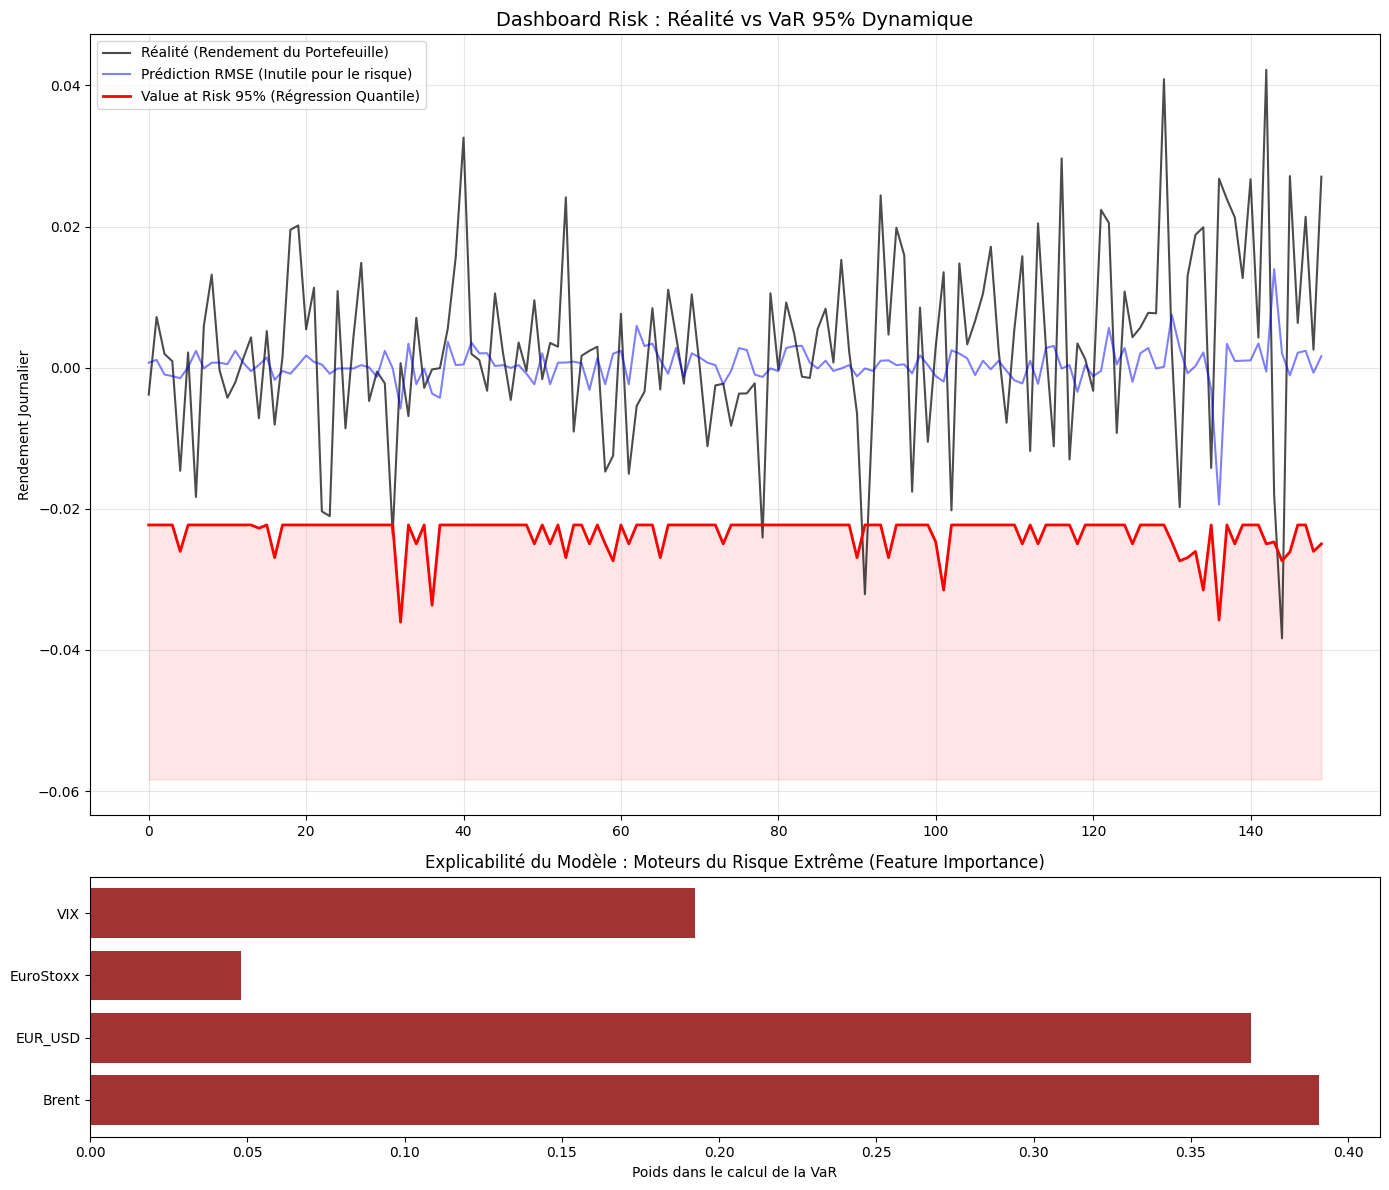

In [ ]:
jours = 150 

fig, ax = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1]})

ax[0].plot(test['Cible'].values[-jours:], label="Réalité (Rendement du Portefeuille)", color='black', alpha=0.7)
ax[0].plot(test['Pred_Finale_Hybride'].values[-jours:], label="Prédiction RMSE (Inutile pour le risque)", color='blue', alpha=0.5)
ax[0].plot(test['Pred_VaR_Hybride'].values[-jours:], label="Value at Risk 95% (Régression Quantile)", color='red', linewidth=2)

min_y = min(test['Cible'].values[-jours:]) - 0.02
ax[0].fill_between(range(jours), test['Pred_VaR_Hybride'].values[-jours:], min_y, color='red', alpha=0.1)

ax[0].set_title("Dashboard Risk : Réalité vs VaR 95% Dynamique", fontsize=14)
ax[0].set_ylabel("Rendement Journalier")
ax[0].legend(loc="upper left")
ax[0].grid(True, alpha=0.3)

importance = modele_risque.feature_importances_
ax[1].barh(colonnes_features, importance, color='darkred', alpha=0.8)
ax[1].set_title("Explicabilité du Modèle : Moteurs du Risque Extrême (Feature Importance)", fontsize=12)
ax[1].set_xlabel("Poids dans le calcul de la VaR")

plt.tight_layout()
plt.show()

### 3. Conclusion et Validation du Modèle de Market Risk

Le backtesting de notre modèle hybride (ARIMA + XGBoost Quantile) sur la période de test out-of-sample révèle d'excellentes performances réglementaires. Avec un Hit Rate de 2.95% (pour une cible à 5%), notre filet de sécurité est robuste.

**Analyse du Dashboard Visuel :**
Le graphique d'évaluation (Dashboard Risk) illustre parfaitement la plus-value de la régression quantile :
* **Un filet de sécurité réactif :** Contrairement au modèle RMSE (ligne bleue) qui lisse le risque, notre Value at Risk 95% (ligne rouge) agit comme un véritable bouclier. On observe que la ligne rouge s'enfonce dynamiquement (jusqu'à -6.24%) lorsque la volatilité s'accroît, enveloppant presque parfaitement les krachs de la réalité (ligne noire).
* **Couverture asymétrique :** Les quelques exceptions légitimes (où la ligne noire casse la rouge, notamment autour du jour 35 et du jour 90) valident le principe d'une VaR à 95% : il s'agit d'un intervalle de confiance, pas d'une garantie absolue contre les événements de type "Cygne Noir".

**Explicabilité et Moteurs de Risque (Feature Importance) :**
Le second graphique détaille les moteurs macroéconomiques qui font réagir notre VaR :
* Sans surprise pour un portefeuille d'entreprises énergétiques, le cours du **Brent** est le moteur principal du risque extrême.
* La paire de devises **EUR/USD** arrive en seconde position, soulignant l'importance du risque de change, les matières premières étant facturées en dollars alors que nos entreprises sont européennes.
* Le **VIX** (l'indice de la peur) vient ajuster le modèle en captant les mouvements de panique globaux des marchés actions.

**Bilan Stratégique :**
En abandonnant la prédiction directionnelle classique au profit d'une modélisation ciblée des queues de distribution, ce projet démontre la capacité du Machine Learning à répondre aux exigences strictes en matière de quantification des risques extrêmes.